# Lab 2: Clasificiación de Malware
Luis Pedro Montenegro - 21699 <br>
Javier Alejandro Prado - <br>


## Preprocesamiento
Limpiar y analizar el set de datos antes del entrenamiento. <br>
Utilizar Python 3.12 para el ambiente.

### Cargando el dataset

In [22]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt

In [23]:
current_directory: str = os.getcwd()
dataset_path: str = f"{current_directory}/MalBehavD-V1-dataset/MalBehavD-V1-dataset.csv" # change according to where the path points to

df: pd.DataFrame = pd.read_csv(dataset_path)
df.head(5)

,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,NtQueryValueKey,LdrUnloadDll,GlobalMemoryStatus,WriteConsoleA,NtOpenKey,LdrGetProcedureAddress,NtTerminateProcess,NtClose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,LdrUnloadDll,GetSystemTimeAsFileTime,NtOpenKey,WSAStartup,SetUnhandledExceptionFilter,NtTerminateProcess,NtClose,NtAllocateVirtualMemory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# count how many items there are
len(df)

2570

### Contando instancias nulas y corrección de las mismas

In [25]:
for col in df.columns:
    null_count:int = df[col].isnull().sum()
    print(f"{col}: {null_count}")

sha256: 0
labels: 0
0: 0
1: 0
2: 6
3: 9
4: 11
5: 20
6: 30
7: 36
8: 73
9: 104
10: 139
11: 175
12: 225
13: 250
14: 285
15: 309
16: 385
17: 415
18: 549
19: 625
20: 855
21: 884
22: 935
23: 953
24: 1034
25: 1044
26: 1050
27: 1067
28: 1077
29: 1108
30: 1123
31: 1136
32: 1155
33: 1179
34: 1197
35: 1226
36: 1270
37: 1298
38: 1332
39: 1370
40: 1419
41: 1455
42: 1476
43: 1507
44: 1526
45: 1545
46: 1560
47: 1575
48: 1681
49: 1801
50: 1812
51: 1822
52: 1838
53: 1848
54: 1873
55: 1885
56: 1904
57: 1913
58: 1936
59: 1952
60: 1966
61: 1981
62: 2001
63: 2020
64: 2038
65: 2053
66: 2063
67: 2086
68: 2096
69: 2108
70: 2121
71: 2130
72: 2132
73: 2139
74: 2148
75: 2154
76: 2160
77: 2167
78: 2183
79: 2195
80: 2204
81: 2205
82: 2214
83: 2216
84: 2223
85: 2231
86: 2240
87: 2246
88: 2259
89: 2270
90: 2301
91: 2310
92: 2341
93: 2355
94: 2366
95: 2391
96: 2405
97: 2418
98: 2423
99: 2434
100: 2440
101: 2447
102: 2452
103: 2454
104: 2460
105: 2462
106: 2467
107: 2470
108: 2470
109: 2483
110: 2487
111: 2490
112: 24

In [26]:
df_not_null = df[df.notnull().all(axis=1)]
print(len(df_not_null))
print(df_not_null.iloc[0, 150:-1])

1
148              MoveFileWithProgressW
149                               send
150                    CryptCreateHash
151                        DeleteFileW
152               CryptAcquireContextA
Unnamed: 155          InternetReadFile
Unnamed: 156       CryptDecodeObjectEx
Unnamed: 157    GetTimeZoneInformation
Unnamed: 158             InternetOpenA
Unnamed: 159               GetFileType
Unnamed: 160                   connect
Unnamed: 161         GetShortPathNameW
Unnamed: 162             CryptHashData
Unnamed: 163            Process32NextW
Unnamed: 164            Module32FirstW
Unnamed: 165           Process32FirstW
Unnamed: 166             CertOpenStore
Unnamed: 167             Module32NextW
Unnamed: 168             __exception__
Unnamed: 169          InternetOpenUrlA
Unnamed: 170              GetTempPathW
Unnamed: 171             FindResourceA
Unnamed: 172        GetVolumePathNameW
Unnamed: 173                WSASocketW
Unnamed: 174        NtTerminateProcess
Unnamed: 175           

### Limpieza de datos
**Fase 1:** Eliminar columnas vacías y analizar estructura del dataset.

In [27]:
# Fase 1: Identificar y eliminar columnas completamente vacías
print(f"Columnas originales: {df.shape[1]}")

# Encontrar columnas completamente vacías (todos los valores son NaN)
empty_cols = df.columns[df.isnull().all()].tolist()
print(f"\nColumnas completamente vacías ({len(empty_cols)}): {empty_cols}")

# Eliminar columnas vacías
df_clean = df.drop(columns=empty_cols)
print(f"\nColumnas después de limpieza: {df_clean.shape[1]}")
print(f"Filas: {df_clean.shape[0]}")

Columnas originales: 177

Columnas completamente vacías (0): []

Columnas después de limpieza: 177
Filas: 2570


### Análisis de distribución de labels y balance de clases

Distribución de clases:
labels
0    1285
1    1285
Name: count, dtype: int64

Ratio malware/benigno: 1.00


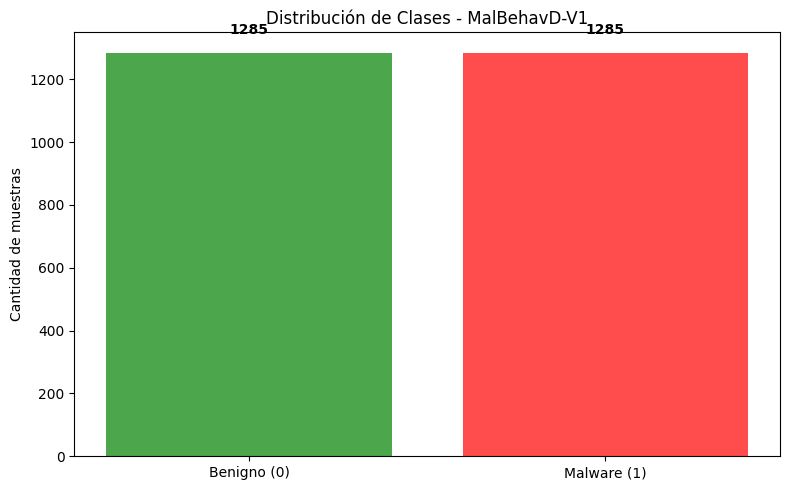

In [34]:
# Distribución de labels (0=benigno, 1=malware)
label_counts = df_clean['labels'].value_counts()
print("Distribución de clases:")
print(label_counts)
print(f"\nRatio malware/benigno: {label_counts.get(1, 0) / label_counts.get(0, 1):.2f}")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Benigno (0)', 'Malware (1)'], [label_counts.get(0, 0), label_counts.get(1, 0)], 
              color=['green', 'red'], alpha=0.7)
ax.set_ylabel('Cantidad de muestras')
ax.set_title('Distribución de Clases - MalBehavD-V1')
for bar, count in zip(bars, [label_counts.get(0, 0), label_counts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count), 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis de valores nulos en secuencias de API calls

Estadísticas de longitud de secuencias:
  Mínimo: 2
  Máximo: 175
  Media: 43.19
  Mediana: 37.0
  Percentil 95: 101.0
  Percentil 99: 126.0

Muestras sin API calls: 0


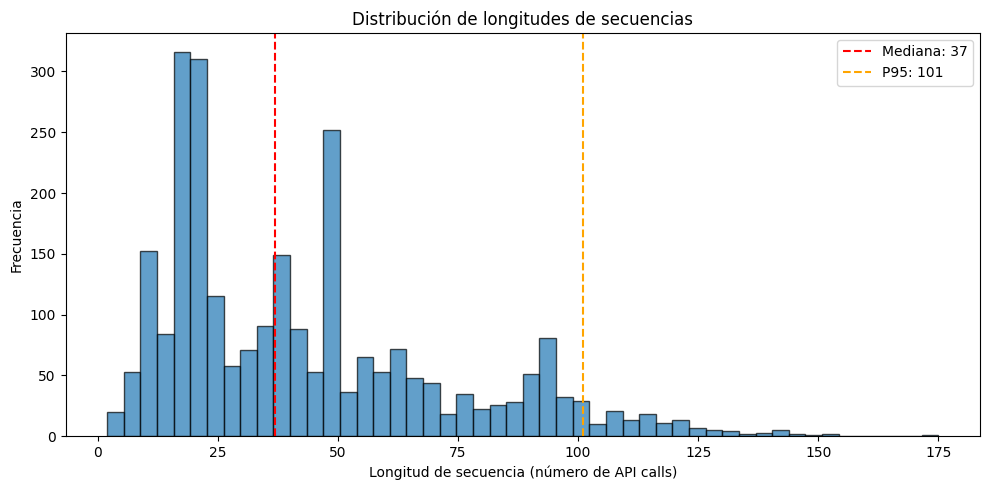

In [28]:
# Analizar longitud de secuencias (cuántos API calls por muestra)
api_cols = [col for col in df_clean.columns if col not in ['sha256', 'labels']]

# Contar API calls no nulos por fila
sequence_lengths = df_clean[api_cols].notna().sum(axis=1)

print(f"Estadísticas de longitud de secuencias:")
print(f"  Mínimo: {sequence_lengths.min()}")
print(f"  Máximo: {sequence_lengths.max()}")
print(f"  Media: {sequence_lengths.mean():.2f}")
print(f"  Mediana: {sequence_lengths.median()}")
print(f"  Percentil 95: {sequence_lengths.quantile(0.95)}")
print(f"  Percentil 99: {sequence_lengths.quantile(0.99)}")

# Muestras sin API calls (longitud 0)
zero_length = (sequence_lengths == 0).sum()
print(f"\nMuestras sin API calls: {zero_length}")

# Visualización de distribución de longitudes
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sequence_lengths, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(sequence_lengths.median(), color='red', linestyle='--', label=f'Mediana: {sequence_lengths.median():.0f}')
ax.axvline(sequence_lengths.quantile(0.95), color='orange', linestyle='--', label=f'P95: {sequence_lengths.quantile(0.95):.0f}')
ax.set_xlabel('Longitud de secuencia (número de API calls)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitudes de secuencias')
ax.legend()
plt.tight_layout()
plt.show()

### Fase 2: Crear vocabulario de API calls y codificación

In [29]:
import numpy as np
from collections import Counter

# Extraer todos los API calls únicos del dataset
all_api_calls = []
for col in api_cols:
    api_values = df_clean[col].dropna().unique()
    all_api_calls.extend(api_values)

# Contar frecuencia de cada API call
api_counter = Counter(all_api_calls)
print(f"API calls únicos totales: {len(api_counter)}")

# Mostrar los 20 API calls más frecuentes
print("\nTop 20 API calls más frecuentes:")
for api, count in api_counter.most_common(20):
    print(f"  {api}: {count}")

# API calls raros (aparecen menos de 5 veces)
rare_apis = [api for api, count in api_counter.items() if count < 5]
print(f"\nAPI calls raros (<5 ocurrencias): {len(rare_apis)}")

API calls únicos totales: 291

Top 20 API calls más frecuentes:
  NtOpenKeyEx: 120
  GetFileAttributesExW: 112
  GetTempPathW: 112
  GetFileType: 109
  NtOpenKey: 109
  NtQueryDirectoryFile: 107
  NtCreateMutant: 106
  FindResourceW: 105
  GetFileVersionInfoW: 105
  SetUnhandledExceptionFilter: 103
  NtUnmapViewOfSection: 103
  NtTerminateProcess: 102
  NtOpenFile: 102
  NtQueryAttributesFile: 102
  CreateProcessInternalW: 101
  NtDelayExecution: 101
  NtQueryKey: 100
  OleInitialize: 100
  SizeofResource: 99
  IsDebuggerPresent: 98

API calls raros (<5 ocurrencias): 36


In [30]:
# Crear vocabulario con tokens especiales
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Construir vocabulario (excluir API calls muy raros)
vocab_apis = [api for api, count in api_counter.items() if count >= 5]
vocab = [PAD_TOKEN, UNK_TOKEN] + sorted(vocab_apis)

# Crear mapeos
api_to_idx = {api: idx for idx, api in enumerate(vocab)}
idx_to_api = {idx: api for api, idx in api_to_idx.items()}

print(f"Tamaño del vocabulario: {len(vocab)}")
print(f"  - Tokens especiales: 2 ({PAD_TOKEN}, {UNK_TOKEN})")
print(f"  - API calls: {len(vocab) - 2}")
print(f"\nPrimeros 10 elementos del vocabulario:")
for i, api in enumerate(vocab[:10]):
    print(f"  {i}: {api}")

Tamaño del vocabulario: 257
  - Tokens especiales: 2 (<PAD>, <UNK>)
  - API calls: 255

Primeros 10 elementos del vocabulario:
  0: <PAD>
  1: <UNK>
  2: CertControlStore
  3: CertOpenStore
  4: CoCreateInstance
  5: CoCreateInstanceEx
  6: CoGetClassObject
  7: CoInitializeEx
  8: CoInitializeSecurity
  9: CoUninitialize


### Fase 3: Codificar secuencias y normalizar longitud

In [31]:
# Definir longitud máxima basada en percentil 95
MAX_SEQ_LENGTH = int(sequence_lengths.quantile(0.95))
print(f"Longitud máxima de secuencia: {MAX_SEQ_LENGTH}")

def encode_sequence(row, api_cols, api_to_idx, max_length):
    """Codifica una secuencia de API calls a índices."""
    sequence = []
    for col in api_cols:
        api = row[col]
        if pd.isna(api):
            break  # Fin de la secuencia
        # Usar UNK_TOKEN para APIs no en vocabulario
        idx = api_to_idx.get(api, api_to_idx[UNK_TOKEN])
        sequence.append(idx)
    
    # Truncar si es muy larga
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    
    # Padding al final
    padding_length = max_length - len(sequence)
    sequence.extend([api_to_idx[PAD_TOKEN]] * padding_length)
    
    return sequence

# Codificar todas las secuencias
print("Codificando secuencias...")
encoded_sequences = []
for idx, row in df_clean.iterrows():
    encoded = encode_sequence(row, api_cols, api_to_idx, MAX_SEQ_LENGTH)
    encoded_sequences.append(encoded)

X = np.array(encoded_sequences)
y = df_clean['labels'].values

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nEjemplo de secuencia codificada (primeros 20 tokens):")
print(f"  {X[0][:20]}")

Longitud máxima de secuencia: 101
Codificando secuencias...

Forma de X: (2570, 101)
Forma de y: (2570,)

Ejemplo de secuencia codificada (primeros 20 tokens):
  [112   9 154 135  69  72 108  76 126  63 146  55 198 140 205  58 194 213
 161 125]


### Fase 4: División train/validation/test y guardado

In [32]:
from sklearn.model_selection import train_test_split
import json

# División estratificada: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 15/85
)

print("División del dataset:")
print(f"  Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada split
print("\nDistribución de clases por split:")
for name, y_split in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    benign = (y_split == 0).sum()
    malware = (y_split == 1).sum()
    print(f"  {name}: Benigno={benign}, Malware={malware}, Ratio={malware/benign:.2f}")

División del dataset:
  Train: 1799 muestras (70.0%)
  Validation: 385 muestras (15.0%)
  Test: 386 muestras (15.0%)

Distribución de clases por split:
  Train: Benigno=899, Malware=900, Ratio=1.00
  Validation: Benigno=193, Malware=192, Ratio=0.99
  Test: Benigno=193, Malware=193, Ratio=1.00


In [33]:
# Guardar datos procesados
output_dir = f"{current_directory}/processed_data"
os.makedirs(output_dir, exist_ok=True)

# Guardar arrays numpy
np.save(f"{output_dir}/X_train.npy", X_train)
np.save(f"{output_dir}/X_val.npy", X_val)
np.save(f"{output_dir}/X_test.npy", X_test)
np.save(f"{output_dir}/y_train.npy", y_train)
np.save(f"{output_dir}/y_val.npy", y_val)
np.save(f"{output_dir}/y_test.npy", y_test)

# Guardar vocabulario
vocab_data = {
    'api_to_idx': api_to_idx,
    'idx_to_api': {str(k): v for k, v in idx_to_api.items()},  # JSON requiere keys string
    'vocab_size': len(vocab),
    'max_seq_length': MAX_SEQ_LENGTH,
    'pad_idx': api_to_idx[PAD_TOKEN],
    'unk_idx': api_to_idx[UNK_TOKEN]
}

with open(f"{output_dir}/vocabulary.json", 'w') as f:
    json.dump(vocab_data, f, indent=2)

print(f"Datos guardados en: {output_dir}")
print(f"\nArchivos creados:")
for f_name in os.listdir(output_dir):
    file_path = os.path.join(output_dir, f_name)
    size = os.path.getsize(file_path)
    print(f"  {f_name}: {size/1024:.1f} KB")

Datos guardados en: c:\Users\javil\OneDrive\Documentos\U\Data Science\Lab2-SecurityDataScience/processed_data

Archivos creados:
  vocabulary.json: 15.2 KB
  X_test.npy: 304.7 KB
  X_train.npy: 1419.6 KB
  X_val.npy: 303.9 KB
  y_test.npy: 3.1 KB
  y_train.npy: 14.2 KB
  y_val.npy: 3.1 KB


### Resumen del preprocesamiento
El dataset ha sido limpiado y preparado para modelos de Deep Learning/NLP:
- **Columnas vacías eliminadas**: Se removieron las columnas sin datos
- **Vocabulario creado**: Mapeo de API calls a índices enteros
- **Secuencias codificadas**: Cada muestra es un array de índices de longitud fija
- **Datos divididos**: Train/Validation/Test con stratificación por clase